In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
cell_type_names = [
    "B", "CD4+ T cell", "CD57+ Enterocyte", "CD66+ Enterocyte", "CD7+ Immune",
    "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte",
    "Goblet", "ICC", "Lymphatic", "M1 Macrophage", "M2 Macrophage",
    "MUC1+ Enterocyte", "NK", "Nerve", "Neuroendocrine", "Neutrophil",
    "Paneth", "Plasma", "Smooth muscle", "Stroma", "TA"
]

# Cell type colors
type_color_dict = {
    1: [134.9, 124.1, 8.7],
    2: [62.3, 216.0, 132.0],
    3: [130.9, 46.4, 182.5],
    4: [92.8, 63.6, 202.5],
    5: [140.1, 239.7, 189.0],
    6: [200.0, 183.1, 168.9],
    7: [108.3, 16.1, 142.3],
    8: [132.7, 217.1, 223.4],
    9: [170.6, 96.0, 98.0],
    10: [68.4, 101.1, 101.3],
    11: [4.6, 146.9, 145.6],
    12: [177.1, 1.5, 112.2],
    13: [202.6, 136.4, 12.3],
    14: [95.1, 244.3, 209.6],
    15: [32.5, 214.2, 217.8],
    16: [176.2, 78.6, 193.2],
    17: [185.9, 206.0, 77.8],
    18: [212.0, 39.3, 35.0],
    19: [117.1, 190.4, 53.4],
    20: [101.2, 145.2, 246.9],
    21: [13.7, 179.1, 133.2],
    22: [247.4, 125.5, 111.5],
    23: [122.9, 151.0, 150.0],
    24: [118.0, 45.6, 47.7],
    25: [31.1, 114.7, 222.5]
}

In [ ]:
# train_conditional_ddpm_x0_with_composition.py
# 512x512 条件扩散：输入 noisy(x_t) + cond(recon)，预测原图 x0（x0-parameterization）
# 训练：不做mask；验证阶段：绘制对比图 + 统计“全验证集平均”cell-type分布（排除白像素）
# 依赖：torch, torchvision, pillow, numpy, tqdm, matplotlib

import os, math, glob
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, utils as vutils
from torchvision.utils import save_image
from tqdm import tqdm
import matplotlib.pyplot as plt

# -------------------- 公用工具 --------------------
def to_uint8(img_tensor):  # [-1,1] -> uint8 HxWxC
    img = (img_tensor.clamp(-1, 1) + 1) * 0.5
    img = (img * 255.0).round().clamp(0, 255).to(torch.uint8)
    return img

def denorm_01(x):  # [-1,1] -> [0,1]
    return ((x.clamp(-1,1) + 1.0) * 0.5).clamp(0,1)

THRESH_WHITE_01 = 250.0/255.0  # “RGB>250/255 视为白（仅用于组成统计）”

# -------------------- 数据集 --------------------
import os, glob, random
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF

class PairImageDataset(Dataset):
    def __init__(self, root="data", size=512,
                 orig_suffix="_orig.png", recon_suffix="_recon.png",
                 augment=True):
        self.size = size
        self.augment = augment

        # -------- 匹配 *_orig.png 和 *_recon.png --------
        orig_paths = sorted(glob.glob(os.path.join(root, f"*{orig_suffix}")))
        self.pairs = []
        for op in orig_paths:
            prefix = os.path.basename(op)[:-len(orig_suffix)]
            rp = os.path.join(root, f"{prefix}{recon_suffix}")
            if os.path.exists(rp):
                self.pairs.append((rp, op))
            else:
                print(f"[WARN] 找不到配对的重建图: {rp}")
        assert len(self.pairs) > 1, "请至少放置 2 对 *_orig/_recon 以做 train/test 划分"

        self.size = size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        recon_path, orig_path = self.pairs[idx]
        recon_img = Image.open(recon_path).convert("RGB")
        orig_img  = Image.open(orig_path).convert("RGB")

        # -------- 数据增强（同步应用） --------
        if self.augment:
            # 随机水平翻转
            if random.random() < 0.5:
                recon_img = TF.hflip(recon_img)
                orig_img  = TF.hflip(orig_img)
            # 随机垂直翻转
            if random.random() < 0.5:
                recon_img = TF.vflip(recon_img)
                orig_img  = TF.vflip(orig_img)
            # 随机 90° 倍数旋转
            k = random.choice([0, 1, 2, 3])  # 旋转 0/90/180/270
            if k > 0:
                recon_img = recon_img.rotate(90 * k, expand=True)
                orig_img  = orig_img.rotate(90 * k, expand=True)

        d = TF.to_tensor(recon_img)
        o = TF.to_tensor(orig_img)

        # 归一化到 [-1,1]
        d = TF.normalize(d, [0.5]*3, [0.5]*3)
        o = TF.normalize(o, [0.5]*3, [0.5]*3)

        return d, o


def create_data_loaders(root, size, batch_size, num_workers, test_ratio=0.1, seed=42):
    fullset = PairImageDataset(root=root, size=size)
    n = len(fullset)
    idx = np.arange(n); rng = np.random.default_rng(seed); rng.shuffle(idx)
    n_test = max(1, int(round(n * test_ratio)))
    test_idx = idx[:n_test].tolist(); train_idx = idx[n_test:].tolist()
    assert len(train_idx) > 0, "训练集为空，请增大数据或减小 test_ratio"
    train_set = Subset(fullset, train_idx); test_set = Subset(fullset, test_idx)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True, drop_last=True,
                              persistent_workers=(num_workers>0))
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True, drop_last=False,
                              persistent_workers=(num_workers>0))
    return train_loader, test_loader

# -------------------- Autoencoder（仅用于验证阶段的组成统计） --------------------
class Autoencoder(nn.Module):
    def __init__(self, in_dim=25, bottleneck_dim=3, hidden_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim)), nn.ReLU(), nn.LayerNorm(int(hidden_dim)), nn.Dropout(0.1),
            nn.Linear(hidden_dim, int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), hidden_dim), nn.ReLU(), nn.LayerNorm(int(hidden_dim)), nn.Dropout(0.1),
            nn.Linear(hidden_dim, int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), in_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)

# z3d 缩放常量
_MIN_VALS = torch.tensor([-69.761505, -75.65188, -77.16103], dtype=torch.float32)
_MAX_VALS = torch.tensor([ 88.969406,  65.244896, 67.13518 ], dtype=torch.float32)
_RANGE    = _MAX_VALS - _MIN_VALS


import torchvision.models as models

class VGGPerceptualLoss(torch.nn.Module):
    def __init__(self, resize=True):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_FEATURES).features
        self.blocks = torch.nn.ModuleList([
            vgg[:4],   # relu1_2
            vgg[4:9],  # relu2_2
            vgg[9:16], # relu3_3
            vgg[16:23] # relu4_3
        ])
        for bl in self.blocks:
            for p in bl.parameters():
                p.requires_grad = False
        self.resize = resize

    def forward(self, x, y):
        # expect [B,3,H,W], [0,1] range
        if self.resize:
            import torch.nn.functional as F
            x = F.interpolate(x, size=(224,224), mode='bilinear', align_corners=False)
            y = F.interpolate(y, size=(224,224), mode='bilinear', align_corners=False)
        loss = 0.0
        for bl in self.blocks:
            x = bl(x); y = bl(y)
            loss += F.l1_loss(x, y)
        return loss

def reweighted_jsd_loss(p, q, class_weights=None, eps=1e-8): ##LEYLA
  ###
    """
    p, q: [B,K], already sum to 1
    class_weights: [K] or None
    """
    p = p.clamp(min=eps)
    q = q.clamp(min=eps)
    m = 0.5 * (p + q)
    jsd = 0.5 * (p * (torch.log(p) - torch.log(m)) +
                 q * (torch.log(q) - torch.log(m)))  # [B,K]

    if class_weights is not None:
        w = class_weights.to(p.device)
        jsd = jsd * w.unsqueeze(0)  # broadcast [1,K] → [B,K]

    return jsd.sum(dim=1).mean()

def jsd_loss(p, q, eps=1e-8):
    # p, q: [B, K] (already sum to 1)
    p = p.clamp(min=eps)
    q = q.clamp(min=eps)
    m = 0.5 * (p + q)
    # use ln or log2: using natural log is fine; scaling doesn't matter for λ
    return 0.5 * (torch.sum(p * (torch.log(p) - torch.log(m)), dim=1) +
                  torch.sum(q * (torch.log(q) - torch.log(m)), dim=1)).mean()

import torch
import torch.nn.functional as F


def dynamic_class_weights(fracs_gt, eps=1e-3):
    """
    fracs_gt: [B,K], ground-truth fractions
    return: [K] tensor of weights
    """
    mean_frac = fracs_gt.mean(dim=0)                # [K]
    inv_freq  = 1.0 / (mean_frac + eps)             # 稀有类别 → 大权重
    weights   = inv_freq / inv_freq.sum()           # 归一化
    return weights.detach()                         # 不反传梯度


def soft_fractions_from_batch_rgb(imgs_m11, ae_model, temp=0.35): ##LEYLA
#extract composition from the original tissue/ground truth
    """
    imgs_m11: [B,3,H,W] ∈ [-1,1]
    返回: fractions [B,25] 可微
    """
    device = next(ae_model.parameters()).device
    B, _, H, W = imgs_m11.shape
    x01 = denorm_01(imgs_m11)  # [-1,1] -> [0,1]
    mv = _MIN_VALS.to(device)
    rg = _RANGE.to(device)
    thr = THRESH_WHITE_01

    fracs = []
    for i in range(B):
        rgb = x01[i].to(device)                     # [3,H,W]
        flat = rgb.permute(1,2,0).reshape(-1,3)    # [N,3]
        mask = (flat > thr).all(dim=1)             # 白色 mask
        valid = flat[~mask]                         # [M,3]

        if valid.numel() == 0:
            fracs.append(torch.zeros(25, device=device))
            continue

        z = valid * rg + mv                          # 恢复原尺度
        logits = ae_model.decoder(z)                 # [M,25]
        probs  = F.softmax(logits / temp, dim=1)     # 可微 softmax
        frac   = probs.mean(dim=0)                   # [25], 平均概率作为 fraction
        fracs.append(frac)

    return torch.stack(fracs, dim=0)                # [B,25]



@torch.no_grad()
def fractions_from_batch_rgb(imgs_m11, ae_model):
    """
    imgs_m11: [B,3,H,W] ∈ [-1,1]；组成统计时剔除“白像素”（RGB>250/255）
    返回: fractions [B,25]、valid_pixels [B]
    """
    device = next(ae_model.parameters()).device
    B, _, H, W = imgs_m11.shape
    x01 = denorm_01(imgs_m11)
    mv = _MIN_VALS.to(device); rg = _RANGE.to(device); thr = THRESH_WHITE_01

    fracs = []; pixs = []
    for i in range(B):
        rgb = x01[i].to(device)                        # [3,H,W]
        flat = rgb.permute(1,2,0).reshape(-1,3)
        white = (flat > thr).all(dim=1)               # 只在统计时剔除白
        valid = flat[~white]
        if valid.numel() == 0:
            fracs.append(torch.zeros(25, device="cpu")); pixs.append(0); continue
        z = valid * rg + mv                            # 恢复 z3d
        logits = ae_model.decoder(z)                   # [N,25]
        pred = torch.argmax(logits, dim=1)             # 0..24
        cnt  = torch.bincount(pred, minlength=25).float().cpu()
        fracs.append(cnt / cnt.sum().clamp_min(1))
        pixs.append(int(cnt.sum().item()))
    return torch.stack(fracs, 0), np.array(pixs, dtype=np.int64)

# -------------------- 时间嵌入 & 模块 --------------------
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        device = t.device; half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=device) / (half - 1))
        args = t[:, None].float() * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return F.pad(emb, (0,1)) if self.dim % 2 == 1 else emb

class TimeMLP(nn.Module):
    def __init__(self, dim, out):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim, out), nn.SiLU(), nn.Linear(out, out))
    def forward(self, t_emb): return self.net(t_emb)

def conv3x3(in_c, out_c): return nn.Conv2d(in_c, out_c, 3, padding=1)

def _gn_groups(c):
    g = min(32, c)
    while c % g != 0 and g > 1:
        g //= 2
    return g

class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, time_dim):
        super().__init__()
        g1 = _gn_groups(in_c); g2 = _gn_groups(out_c)
        self.norm1 = nn.GroupNorm(g1, in_c); self.act1 = nn.SiLU(); self.conv1 = conv3x3(in_c, out_c)
        self.norm2 = nn.GroupNorm(g2, out_c); self.act2 = nn.SiLU(); self.conv2 = conv3x3(out_c, out_c)
        self.time  = nn.Linear(time_dim, out_c)
        self.skip  = nn.Identity() if in_c == out_c else nn.Conv2d(in_c, out_c, 1)
    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time(t_emb)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        return h + self.skip(x)

class ResStack(nn.Module):
    def __init__(self, blocks):
        super().__init__(); self.blocks = nn.ModuleList(blocks)
    def forward(self, x, t_emb):
        for b in self.blocks: x = b(x, t_emb)
        return x

class Down(nn.Module):
    def __init__(self, c): super().__init__(); self.op = nn.Conv2d(c, c, 4, stride=2, padding=1)
    def forward(self, x): return self.op(x)

class Up(nn.Module):
    def __init__(self, c): super().__init__(); self.op = nn.Sequential(nn.Upsample(scale_factor=2, mode="nearest"), conv3x3(c, c))
    def forward(self, x): return self.op(x)

# -------------------- Cond 编码 & Cross-Attn & 高分融合 --------------------
class ConvGNAct(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.norm = nn.GroupNorm(_gn_groups(in_c), in_c)
        self.act  = nn.SiLU()
        self.conv = nn.Conv2d(in_c, out_c, 3, padding=1)
    def forward(self, x): return self.conv(self.act(self.norm(x)))

class CondEncoder(nn.Module):
    def __init__(self, in_ch=3, chans=(160,320,640,1280)):  # 128*1.25=160
        super().__init__()
        self.stem = nn.Conv2d(in_ch, chans[0], 3, padding=1)
        downs, blocks = [], []
        in_c = chans[0]
        for i, c in enumerate(chans):
            blocks.append(nn.Sequential(ConvGNAct(in_c, c), ConvGNAct(c, c)))
            in_c = c
            if i < len(chans) - 1:
                downs.append(nn.Conv2d(in_c, in_c, 4, stride=2, padding=1))
        self.blocks = nn.ModuleList(blocks); self.downs = nn.ModuleList(downs)
    def forward(self, x):
        feats = []
        x = self.stem(x)
        for i, blk in enumerate(self.blocks):
            x = blk(x); feats.append(x)
            if i < len(self.blocks) - 1: x = self.downs[i](x)
        return feats  # [512,256,128,64]

class CrossAttention2D(nn.Module):
    def __init__(self, dim_q, dim_kv, heads=4, dropout=0.0):
        super().__init__()
        cand = [8,6,4,3,2,1]
        self.heads = next((h for h in cand if dim_q % h == 0), 1)
        self.scale = (dim_q // self.heads) ** -0.5
        self.to_q = nn.Conv2d(dim_q, dim_q, 1, bias=False)
        self.to_k = nn.Conv2d(dim_kv, dim_q, 1, bias=False)
        self.to_v = nn.Conv2d(dim_kv, dim_q, 1, bias=False)
        self.proj = nn.Conv2d(dim_q, dim_q, 1)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, context):
        B, C, H, W = x.shape
        q = self.to_q(x); k = self.to_k(context); v = self.to_v(context)
        h = self.heads
        def split(t): return t.view(B, h, C//h, H*W).permute(0,1,3,2)
        q, k, v = split(q), split(k), split(v)
        attn = (q @ k.transpose(-2,-1)) * self.scale
        attn = self.drop(attn.softmax(dim=-1))
        out = attn @ v
        out = out.permute(0,1,3,2).contiguous().view(B, C, H, W)
        return self.proj(out)

class HighResFuse(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.dw = nn.Conv2d(2*c, 2*c, 3, padding=1, groups=2*c)
        self.pw = nn.Conv2d(2*c, c, 1)
        self.norm = nn.GroupNorm(_gn_groups(c), c)
        self.act  = nn.SiLU()
        hidden = max(8, c // 16)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(c, hidden, 1), nn.SiLU(),
            nn.Conv2d(hidden, c, 1), nn.Sigmoid()
        )
    def forward(self, x, cond_feat):
        h = torch.cat([x, cond_feat], dim=1)
        h = self.dw(h); h = self.pw(h)
        h = self.act(self.norm(h))
        h = h * self.se(h)
        return x + h

# -------------------- 条件 UNet（预测 x0） --------------------
class ConditionalUNet(nn.Module):
    def __init__(self,
                 base=128, ch_mult=(1,2,4,8), width_scale=1.25,
                 blocks_per_stage=3, time_dim=320,
                 in_channels=6, out_channels=3,
                 in_res=512,
                 attn_res={64},
                 highres_res={128,256,512},
                 attn_heads=4, attn_dropout=0.0):
        super().__init__()
        self.attn_res    = set(attn_res)
        self.highres_res = set(highres_res)
        self.time_mlp = nn.Sequential(SinusoidalPosEmb(time_dim), TimeMLP(time_dim, time_dim))

        chans = [int(base * width_scale) * m for m in ch_mult]  # e.g. [160,320,640,1280]
        self.chans = chans
        self.res_list = [in_res // (2**i) for i in range(len(chans))]  # [512,256,128,64]

        self.cond_enc = CondEncoder(in_ch=3, chans=chans)
        self.in_conv = conv3x3(in_channels, chans[0])

        # 下采样
        self.downs = nn.ModuleList()
        self.res_down = nn.ModuleList()
        self.ca_down = nn.ModuleList()
        self.proj_down = nn.ModuleList()
        self.fuse_down = nn.ModuleList()

        in_c = chans[0]
        for i, c in enumerate(chans):
            blocks = [ResBlock(in_c, c, time_dim)]
            for _ in range(blocks_per_stage - 1):
                blocks.append(ResBlock(c, c, time_dim))
            self.res_down.append(ResStack(blocks))

            res_here = self.res_list[i]
            self.ca_down.append(CrossAttention2D(dim_q=c, dim_kv=c, heads=attn_heads, dropout=attn_dropout))
            self.proj_down.append(nn.Conv2d(c, c, 1))
            self.fuse_down.append(HighResFuse(c) if res_here in self.highres_res else nn.Identity())

            in_c = c
            if i < len(chans)-1:
                self.downs.append(Down(in_c))

        # bottleneck
        self.mid = ResStack([ResBlock(in_c, in_c, time_dim), ResBlock(in_c, in_c, time_dim)])
        self.ca_mid   = CrossAttention2D(dim_q=in_c, dim_kv=in_c, heads=attn_heads, dropout=0.0)
        self.proj_mid = nn.Conv2d(in_c, in_c, 1)
        self.fuse_mid = HighResFuse(in_c) if (self.res_list[-1] in self.highres_res) else nn.Identity()

        # 上采样
        self.ups = nn.ModuleList()
        self.res_up = nn.ModuleList()
        self.ca_up = nn.ModuleList()
        self.proj_up = nn.ModuleList()
        self.fuse_up = nn.ModuleList()

        for i in reversed(range(len(chans))):
            c = chans[i]
            blocks = [ResBlock(in_c + c, c, time_dim)]
            for _ in range(blocks_per_stage - 1):
                blocks.append(ResBlock(c, c, time_dim))
            self.res_up.append(ResStack(blocks))

            res_here = self.res_list[i]
            self.ca_up.append(CrossAttention2D(dim_q=c, dim_kv=c, heads=attn_heads, dropout=0.0))
            self.proj_up.append(nn.Conv2d(c, c, 1))
            self.fuse_up.append(HighResFuse(c) if res_here in self.highres_res else nn.Identity())

            in_c = c
            if i > 0:
                self.ups.append(Up(in_c))

        # 预测 x0：用 tanh 限幅到 [-1,1]
        self.out = nn.Sequential(nn.GroupNorm(_gn_groups(in_c), in_c), nn.SiLU(), conv3x3(in_c, out_channels))

    def _resize_like(self, feat, ref):
        if feat.shape[2:] != ref.shape[2:]:
            feat = F.interpolate(feat, size=ref.shape[2:], mode="nearest")
        return feat

    def _inject(self, x, cond_feat, res_here, attn_module, proj_module, fuse_module):
        cond_feat = self._resize_like(cond_feat, x)
        if (res_here in self.attn_res):           # 低分辨率：cross-attn
            return x + attn_module(x, cond_feat)
        if isinstance(fuse_module, HighResFuse):  # 高分辨率：强融合
            return fuse_module(x, cond_feat)
        return x + proj_module(cond_feat)         # 其它：退化为 1×1 投影

    def forward(self, x_noisy, t, cond):
        # 预测 x0
        t_emb = self.time_mlp(t)
        cond_feats = self.cond_enc(cond)

        x = torch.cat([x_noisy, cond], dim=1)  # in_channels=6
        x = self.in_conv(x)

        feats = []
        for i, (blk, attn, proj, fuse, down) in enumerate(zip(
            self.res_down, self.ca_down, self.proj_down, self.fuse_down, list(self.downs)+[None]
        )):
            x = blk(x, t_emb)
            x = self._inject(x, cond_feats[i], self.res_list[i], attn, proj, fuse)
            feats.append(x)
            if down is not None: x = down(x)

        x = self.mid(x, t_emb)
        x = self._inject(x, cond_feats[-1], self.res_list[-1], self.ca_mid, self.proj_mid, self.fuse_mid)

        for i, (blk, attn, proj, fuse, up) in enumerate(zip(
            self.res_up, self.ca_up, self.proj_up, self.fuse_up, list(self.ups)+[None]
        )):
            skip = feats.pop()
            x = torch.cat([x, skip], dim=1)
            x = blk(x, t_emb)
            level_idx = len(self.chans) - 1 - i
            x = self._inject(x, cond_feats[level_idx], self.res_list[level_idx], attn, proj, fuse)
            if up is not None: x = up(x)

        return torch.tanh(self.out(x))  # x0 预测（限幅到 [-1,1]）

# -------------------- 扩散日程 & 采样（DDIM, x0-pred） --------------------
class DiffusionSchedule:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=2e-2, device="cuda"):
        self.T = T
        betas = torch.linspace(beta_start, beta_end, T, device=device)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        self.register(betas, alphas, alpha_bar)
    def register(self, betas, alphas, alpha_bar):
        self.betas = betas; self.alphas = alphas; self.alpha_bar = alpha_bar
        self.sqrt_ab = torch.sqrt(alpha_bar); self.sqrt_1m_ab = torch.sqrt(1.0 - alpha_bar)
        self.sqrt_a = torch.sqrt(alphas); self.inv_sqrt_a = 1.0/torch.sqrt(alphas)
    def sample_q(self, x0, t, eps=None):
        B = x0.size(0)
        if eps is None: eps = torch.randn_like(x0)
        sqrt_ab_t = self.sqrt_ab[t].view(B,1,1,1)
        sqrt_1m_ab_t = self.sqrt_1m_ab[t].view(B,1,1,1)
        x_t = sqrt_ab_t * x0 + sqrt_1m_ab_t * eps
        return x_t, eps

@torch.no_grad()
def sample_ddim_x0(model, sched, cond, steps=50, eta=0.0):
    """
    DDIM 采样（x0-parameterization）：
    先用 x0̂=model(x_t,t,cond) 得到 x0̂，再更新到下一步。
    """
    device = cond.device
    B, _, H, W = cond.shape
    T = sched.T
    ts = torch.linspace(T-1, 0, steps, device=device).long()
    x = torch.randn(B, 3, H, W, device=device)

    for i, t in enumerate(ts):
        tt = torch.full((B,), int(t.item()), device=device, dtype=torch.long)
        x0_hat = model(x, tt, cond) # 直接预测 x0
        if i == steps - 1:
            x = x0_hat
            break

        t_next  = ts[min(i+1, steps-1)]
        tt_next = torch.full((B,), int(t_next.item()), device=device, dtype=torch.long)
        ab_t    = sched.alpha_bar[tt].view(B,1,1,1)
        ab_next = sched.alpha_bar[tt_next].view(B,1,1,1)

        # 由 x 和 x0̂ 反推 ε̂（用于 DDIM 方向项）
        eps_hat = (x - torch.sqrt(ab_t) * x0_hat) / torch.sqrt(1 - ab_t + 1e-8)

        # DDIM 更新（eta=0 即确定性）
        eta_tensor = torch.tensor(eta, device=device).view(1,1,1,1)
        sigma_t = eta_tensor * torch.sqrt((1 - ab_next)/(1 - ab_t + 1e-8) * (1 - ab_t/ab_next + 1e-8))
        dir_term = torch.sqrt(torch.clamp(1 - ab_next - sigma_t**2, min=0.0)) * eps_hat
        noise = torch.randn_like(x)
        x = torch.sqrt(ab_next) * x0_hat + dir_term + sigma_t * noise

    return x.clamp(-1, 1)

# -------------------- 可视化：对比图 + 组成分布 --------------------
@torch.no_grad()
def save_compare_grids(model_ema, sched, test_loader, save_dir, epoch, steps_list=(100,200), max_vis=8):
    os.makedirs(save_dir, exist_ok=True)
    try:
        cond, x0 = next(iter(test_loader))
    except StopIteration:
        print("[WARN] 测试集为空，跳过可视化")
        return
    device = next(model_ema.parameters()).device
    cond = cond.to(device); x0 = x0.to(device)
    vis_n = min(cond.shape[0], max_vis)
    cond_vis, x0_vis = cond[:vis_n], x0[:vis_n]

    for s in steps_list:
        pred_vis = sample_ddim_x0(model_ema, sched, cond_vis, steps=s, eta=0.0)
        grid = vutils.make_grid(torch.cat([cond_vis, x0_vis, pred_vis], dim=0), nrow=vis_n)
        img = to_uint8(grid.permute(1,2,0).cpu()).numpy()
        outp = os.path.join(save_dir, f"cmp_epoch_{epoch:03d}_s{s}.png")
        Image.fromarray(img).save(outp)
        print(f"[Visualize] saved {outp} (col: cond | orig | pred@{s})")

@torch.no_grad()
def composition_eval_fullval(model_ema, sched, val_loader, ae_model, save_dir, epoch, steps_list=(100,200)):
    """
    对完整验证集：分别用 DDIM steps ∈ steps_list 生成 pred，统计
    Recon(cond)、Pred、Orig 的**全验证集平均** 25 类占比（排除白像素），各自保存柱状图。
    """
    os.makedirs(save_dir, exist_ok=True)
    device = next(model_ema.parameters()).device

    for s in steps_list:
        all_D, all_P, all_O = [], [], []
        for d, o in val_loader:
            d = d.to(device); o = o.to(device)
            p = sample_ddim_x0(model_ema, sched, d, steps=s, eta=0.0)

            fd, _ = fractions_from_batch_rgb(d, ae_model)  # recon
            fp, _ = fractions_from_batch_rgb(p, ae_model)  # pred
            fo, _ = fractions_from_batch_rgb(o, ae_model)  # orig
            all_D.append(fd); all_P.append(fp); all_O.append(fo)

        D = torch.cat(all_D, 0).mean(0).numpy()
        P = torch.cat(all_P, 0).mean(0).numpy()
        O = torch.cat(all_O, 0).mean(0).numpy()

        # 简单指标（L1 差异）
        l1_recon = float(np.abs(D - O).mean())
        l1_pred  = float(np.abs(P - O).mean())
        print(f"[Comp@{s}] L1(recon,orig)={l1_recon:.4f} | L1(pred,orig)={l1_pred:.4f}")

        # 柱状图
        K = 25; xs = np.arange(K)
        fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
        axes[0].bar(xs, D); axes[0].set_title(f"Recon mean composition (val, s={s})")
        axes[1].bar(xs, P); axes[1].set_title(f"Pred mean composition (val, s={s})")
        axes[2].bar(xs, O); axes[2].set_title(f"Original mean composition (val)")
        ymax = max(0.35, float(max(D.max(), P.max(), O.max())) * 1.1)
        for ax in axes:
            ax.set_ylabel("fraction"); ax.set_ylim(0, ymax); ax.grid(alpha=0.2, axis='y')
        axes[-1].set_xticks(xs); axes[-1].set_xticklabels([f"T{i}" for i in range(1,26)], rotation=90)
        plt.tight_layout()
        outp = os.path.join(save_dir, f"comp_epoch_{epoch:03d}_s{s}.png")
        plt.savefig(outp, dpi=150, bbox_inches="tight"); plt.close()
        print(f"[Composition] saved {outp}")

# -------------------- 训练（x0-loss, 无mask, 无EMA） --------------------
def train(
    data_root="data/regions",
    image_size=512,
    batch_size=2,
    lr=1e-4,
    epochs=20,
    num_workers=4,
    T=1000,
    save_dir="runs/exp_ddpm_x0",
    # 结构控制（保持与你原代码一致）
    width_scale=1.25,
    blocks_per_stage=3,
    attn_res=(64,),            # 低分辨率做 cross-attn
    highres_res=(128,256,512), # 高分辨率强融合
    # 组成分布
    ae_model: Autoencoder = None
):
    os.makedirs(save_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INFO] device = {device}")

    train_loader, val_loader = create_data_loaders(
        root=data_root, size=image_size,
        batch_size=batch_size, num_workers=num_workers,
        test_ratio=0.1, seed=0
    )
    perceptual_loss = VGGPerceptualLoss().to(device)

    model = ConditionalUNet(
        base=160, ch_mult=(1,2,4,8), width_scale=width_scale,
        blocks_per_stage=blocks_per_stage, time_dim=320,
        in_channels=6, out_channels=3,
        in_res=image_size,
        attn_res=set(attn_res),
        highres_res=set(highres_res),
        attn_heads=4, attn_dropout=0.0
    ).to(device)

    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = DiffusionSchedule(T=T, device=device)

    for epoch in range(1, epochs+1):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
        model.train()
        for cond, x0 in pbar:
            cond = cond.to(device); x0 = x0.to(device)
            B = x0.size(0)
            t = torch.randint(0, T, (B,), device=device).long()

            x_t, _ = sched.sample_q(x0, t)

            x0_hat = model(x_t, t, cond)
            fracs_hat = soft_fractions_from_batch_rgb(x0_hat, ae_model)
            fracs_gt  = soft_fractions_from_batch_rgb(x0, ae_model)
            class_weights = dynamic_class_weights(fracs_gt)
            comp_loss = reweighted_jsd_loss(fracs_hat, fracs_gt, class_weights)
            perc_loss = perceptual_loss(denorm_01(x0_hat), denorm_01(x0))

            loss = 0.9*F.mse_loss(x0_hat, x0) + 0.1 * perc_loss# + 0.05 * comp_loss

            #print("comp_loss", comp_loss.item())
            optim.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()

            pbar.set_postfix(loss=float(loss.item()))

        # ===== 每 10 epoch 才验证 =====
        if epoch % 15 == 0:
            model.eval()
            steps_list = [200]

            # 1) 对比图（列：cond | orig | pred@steps）
            save_compare_grids(model, sched, val_loader, save_dir, epoch,
                               steps_list=steps_list, max_vis=8)

            # 2) 组成分布（全验证集平均；仅在统计时剔除白像素）
            if ae_model is not None:
                ae_model.eval()
                composition_eval_fullval(model, sched, val_loader, ae_model,
                                         save_dir, epoch, steps_list=steps_list)

            # ===== 保存权重（与你给的结构一致：放在验证块里） =====
            torch.save({
              "model": model.state_dict(),
              "opt": optim.state_dict(),
              "epoch": epoch
            }, os.path.join(save_dir, f"ckpt_epoch_{epoch:03d}.pt"))


In [ ]:
# -------------------- 直接运行示例 --------------------
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 仅用于验证阶段的组成分布统计
    ae = Autoencoder().to(device).eval()
    ae.load_state_dict(torch.load("drive/MyDrive/newae2.pth", map_location=device))

    train(
        data_root="drive/MyDrive/202509Data_Refinment_Diff",
        image_size=512,
        batch_size=1,          # 512^2 吃显存，按卡调
        lr=2e-5,
        epochs=106,
        num_workers=4,
        T=500,
        save_dir="drive/MyDrive/RefinementOutput",
        width_scale=1,
        blocks_per_stage=3,
        attn_res=(64,),               # 低分辨率做 cross-attn
        highres_res=(128,256,512),    # 高分辨率强融合

        ae_model=ae                   # 验证时做组成分布
    )


[INFO] device = cuda
Downloading: "https://download.pytorch.org/models/vgg16_features-amdegroot-88682ab5.pth" to /root/.cache/torch/hub/checkpoints/vgg16_features-amdegroot-88682ab5.pth


100%|██████████| 528M/528M [00:02<00:00, 196MB/s]
Epoch 15/106: 100%|██████████| 59/59 [00:40<00:00,  1.45it/s, loss=0.424]


[Visualize] saved drive/MyDrive/RefinementOutput/cmp_epoch_015_s200.png (col: cond | orig | pred@200)
[Comp@200] L1(recon,orig)=0.0273 | L1(pred,orig)=0.0302
[Composition] saved drive/MyDrive/RefinementOutput/comp_epoch_015_s200.png


Epoch 30/106: 100%|██████████| 59/59 [00:40<00:00,  1.45it/s, loss=0.231]


[Visualize] saved drive/MyDrive/RefinementOutput/cmp_epoch_030_s200.png (col: cond | orig | pred@200)
[Comp@200] L1(recon,orig)=0.0273 | L1(pred,orig)=0.0229
[Composition] saved drive/MyDrive/RefinementOutput/comp_epoch_030_s200.png


...

Epoch 90/106: 100%|██████████| 59/59 [00:40<00:00,  1.45it/s, loss=0.337]


[Visualize] saved drive/MyDrive/RefinementOutput/cmp_epoch_090_s200.png (col: cond | orig | pred@200)
[Comp@200] L1(recon,orig)=0.0273 | L1(pred,orig)=0.0273
[Composition] saved drive/MyDrive/RefinementOutput/comp_epoch_090_s200.png


Epoch 105/106: 100%|██████████| 59/59 [00:40<00:00,  1.45it/s, loss=0.195]


[Visualize] saved drive/MyDrive/RefinementOutput/cmp_epoch_105_s200.png (col: cond | orig | pred@200)
[Comp@200] L1(recon,orig)=0.0273 | L1(pred,orig)=0.0186
[Composition] saved drive/MyDrive/RefinementOutput/comp_epoch_105_s200.png


Epoch 106/106: 100%|██████████| 59/59 [00:41<00:00,  1.44it/s, loss=0.179]


In [ ]:
def build_transform(image_size: int):
    return transforms.Compose([
        transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)  # -> [-1,1]
    ])

@torch.no_grad()
def load_image_as_tensor(path: str, image_size: int, device: torch.device):
    tf = build_transform(image_size)
    img = Image.open(path).convert("RGB")
    x = tf(img).unsqueeze(0).to(device)  # [1,3,H,W] in [-1,1]
    return x, img

def load_model(ckpt_path: str, image_size: int, device: torch.device,
               base=160, width_scale=1.25, blocks_per_stage=3,
               attn_res=(64,), highres_res=(128,256,512)):
    model = ConditionalUNet(
        base=base, ch_mult=(1,2,4,8), width_scale=width_scale,
        blocks_per_stage=blocks_per_stage, time_dim=320,
        in_channels=6, out_channels=3,
        in_res=image_size,
        attn_res=set(attn_res),
        highres_res=set(highres_res),
        attn_heads=4, attn_dropout=0.0
    ).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    try:
        model.load_state_dict(state, strict=True)
    except Exception as e:
        print(f"[WARN] strict=True 加载失败，退回 strict=False ：{e}")
        model.load_state_dict(state, strict=False)
    model.eval()
    return model

def load_ae_decoder(ae_ckpt: str, device: torch.device) -> Autoencoder:
    ae = Autoencoder()
    sd = torch.load(ae_ckpt, map_location=device)
    if isinstance(sd, dict):
        if "ae" in sd and isinstance(sd["ae"], dict):
            ae.load_state_dict(sd["ae"], strict=False)
        elif "model" in sd and isinstance(sd["model"], dict):
            ae.load_state_dict(sd["model"], strict=False)
        else:
            ae.load_state_dict(sd, strict=False)
    else:
        ae.load_state_dict(sd, strict=False)
    ae.to(device).eval()
    return ae

def show_and_save_compare(cond, pred, orig, out_png, title="Compare"):
    """
    cond/pred/orig: [1,3,H,W] in [-1,1]（orig 可为 None）
    显示并可选保存：cond | (orig |) pred
    """
    parts = [cond]
    if orig is not None: parts.append(orig)
    parts.append(pred)
    ncol = len(parts)
    grid = vutils.make_grid(torch.cat(parts, dim=0), nrow=ncol, padding=2)
    img = to_uint8(grid.permute(1,2,0).cpu()).numpy()
    plt.figure(figsize=(4*ncol, 4))
    plt.imshow(img); plt.axis("off"); plt.title(title)
    plt.show()
    if out_png:
        Image.fromarray(img).save(out_png)
        print(f"[Save] {out_png}")

def plot_and_save_composition(cond, pred, orig, ae, out_png):
    """
    使用 fractions_from_batch_rgb 统计“排除白像素”的 25 类占比。
    orig 可为 None；ae 也可为 None（则跳过统计）。
    """
    if ae is None:
        print("[Info] 未提供 AE 权重，跳过组成分布统计。")
        return

    D, _ = fractions_from_batch_rgb(cond, ae)   # [1,25]
    P, _ = fractions_from_batch_rgb(pred, ae)   # [1,25]
    D = D[0].cpu().numpy()
    P = P[0].cpu().numpy()

    rows = 3 if orig is not None else 2
    fig, axes = plt.subplots(rows, 1, figsize=(14, 3.2*rows), sharex=True)

    xs = np.arange(25)
    axes[0].bar(xs, D); axes[0].set_title("Recon (cond) composition")
    axes[1].bar(xs, P); axes[1].set_title("Pred composition")

    if orig is not None:
        O, _ = fractions_from_batch_rgb(orig, ae)
        O = O[0].cpu().numpy()
        axes[2].bar(xs, O); axes[2].set_title("Original composition")
        ymax = max(0.35, float(max(D.max(), P.max(), O.max())) * 1.1)
        l1_recon = float(np.abs(D - O).mean())
        l1_pred  = float(np.abs(P - O).mean())
        print(f"[Comp] L1(recon,orig)={l1_recon:.4f} | L1(pred,orig)={l1_pred:.4f}")
    else:
        ymax = max(0.35, float(max(D.max(), P.max())) * 1.1)

    for ax in axes:
        ax.set_ylabel("fraction"); ax.set_ylim(0, ymax); ax.grid(alpha=0.2, axis='y')
    axes[-1].set_xticks(xs); axes[-1].set_xticklabels([f"T{i}" for i in range(1,26)], rotation=90)

    plt.tight_layout()
    plt.show()
    if out_png:
        fig.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"[Save] {out_png}")


In [ ]:
# ==== 用户可改动区域 ====
CKPT_PATH   = "drive/MyDrive/exp_ddpm_eps_comp/ckpt_epoch_105.pt"  # 你的训练权重
RECON_PATH  = "3.png"          # 条件图（decoded/recon）
ORIG_PATH   = "1.png"           # 可选：原图，用于对比/统计。若没有可设为 None
AE_CKPT     = "newae2.pth"                                  # 可选：AE 权重，用于组成分布统计。若没有可设为 None

OUTDIR      = "./"
STEPS       = 200          # DDIM 步数
ETA         = 0.0          # DDIM eta（0 为确定性）
DIFF_T      = 1000         # 训练时的扩散总步数
IMAGE_SIZE  = 512          # 与训练保持一致（训练里是统一 resize 到 512）

# 与训练构型保持一致（需要时调整）
BASE             = 160
WIDTH_SCALE      = 1
BLOCKS_PER_STAGE = 3
ATTN_RES         = (64,)
HIGHRES_RES      = (128,256,512)

os.makedirs(OUTDIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] device =", device)


[INFO] device = cuda


[Save] pred -> ./pred.png


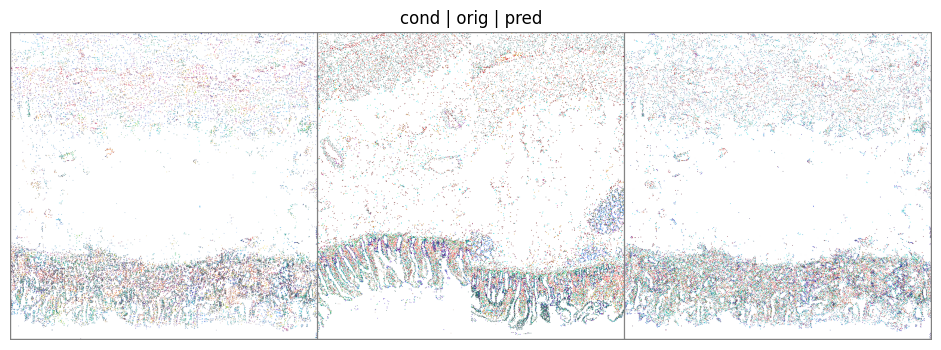

[Save] ./compare.png
[Comp] L1(recon,orig)=0.0306 | L1(pred,orig)=0.0209


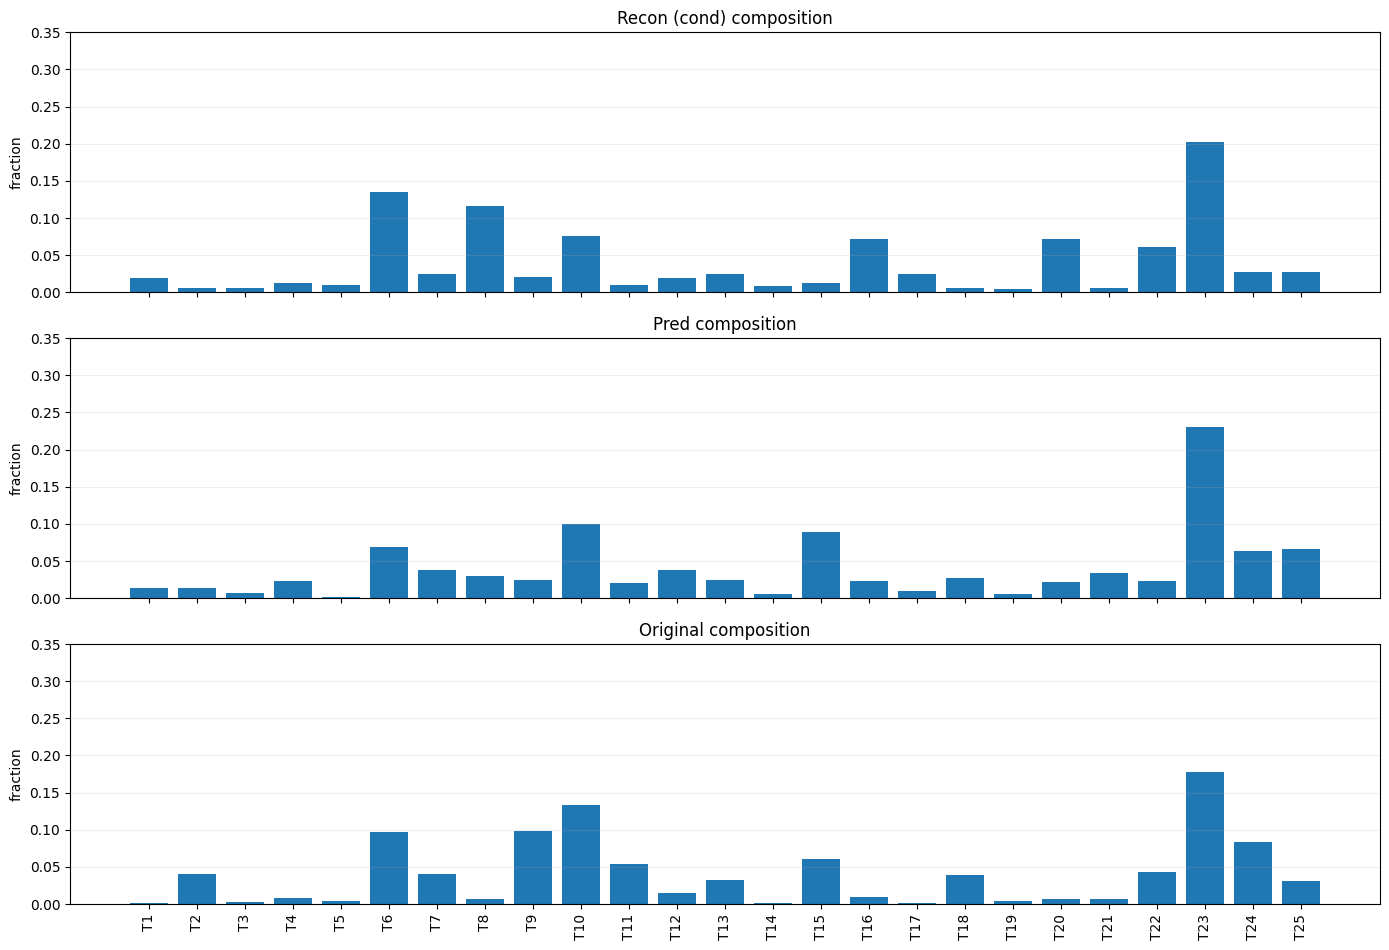

[Save] ./composition.png


In [ ]:
# 1) 加载模型与调度
model = load_model(
    ckpt_path=CKPT_PATH,
    image_size=IMAGE_SIZE,
    device=device,
    base=BASE,
    width_scale=WIDTH_SCALE,
    blocks_per_stage=BLOCKS_PER_STAGE,
    attn_res=ATTN_RES,
    highres_res=HIGHRES_RES
)
sched = DiffusionSchedule(T=DIFF_T, device=device)

# 2) 读入 recon / 可选 orig
cond, cond_pil = load_image_as_tensor(RECON_PATH, IMAGE_SIZE, device)
orig = None
if ORIG_PATH is not None and os.path.isfile(ORIG_PATH):
    orig, _ = load_image_as_tensor(ORIG_PATH, IMAGE_SIZE, device)

# 3) 采样还原
with torch.no_grad():
    pred = sample_ddim_x0(model, sched, cond, steps=STEPS, eta=ETA)  # [-1,1]

# 4) 保存单张预测图
pred_png = os.path.join(OUTDIR, "pred.png")
vutils.save_image(denorm_01(pred[0]), pred_png)
print(f"[Save] pred -> {pred_png}")

# 5) 显示与保存对比图
cmp_png = os.path.join(OUTDIR, "compare.png")
show_and_save_compare(cond, pred, orig, out_png=cmp_png, title=f"cond | {'orig | ' if orig is not None else ''}pred")

ae = load_ae_decoder(AE_CKPT, device)

comp_png = os.path.join(OUTDIR, "composition.png")
plot_and_save_composition(cond, pred, orig, ae, out_png=comp_png if ae is not None else None)

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_pred_vs_orig_distribution_trend(
    pred: torch.Tensor,          # [1,3,H,W] in [-1,1]
    orig: torch.Tensor,          # [1,3,H,W] in [-1,1]
    ae_model,                    # 你的 Autoencoder（用于 fractions_from_batch_rgb）
    type_color_dict: dict,       # {1..25 -> RGB(0..255)}
    cell_type_names: list,       # 长度=25
    num_bins: int = 8,           # 从左到右切几条；512 宽时=8 => 每条 64px
    out_png: str = "pred_vs_orig_distribution_trend.png",
):
    assert pred.ndim == 4 and pred.shape[0] == 1, "pred 需为 [1,3,H,W]"
    assert orig.ndim == 4 and orig.shape[0] == 1, "orig 需为 [1,3,H,W]"
    assert pred.shape[2:] == orig.shape[2:], "pred 与 orig 的 H,W 需一致"
    B, C, H, W = pred.shape
    assert W % num_bins == 0, f"图像宽度 {W} 需能被 num_bins={num_bins} 整除"

    device = next(ae_model.parameters()).device
    bin_w = W // num_bins

    # 1) 计算整张 orig 的 25 类占比
    fracs_orig, _ = fractions_from_batch_rgb(orig.to(device), ae_model)   # [1,25]
    frac_orig = fracs_orig[0].cpu().numpy()                               # (25,)

    # 2) 将 pred 从左到右切成 num_bins 条，批量计算占比
    slices = [pred[:, :, :, i*bin_w:(i+1)*bin_w] for i in range(num_bins)]
    batch = torch.cat(slices, dim=0).to(device)                            # [num_bins,3,H,bin_w]
    fracs_pred, _ = fractions_from_batch_rgb(batch, ae_model)              # [num_bins,25]
    ratios_pred = fracs_pred.cpu().numpy()                                 # (num_bins,25)

    # 3) 组合：最左边是 orig，然后 1..num_bins 是条带
    #    => ratios_all: (1+num_bins, 25)
    ratios_all = np.concatenate([frac_orig[None, :], ratios_pred], axis=0)
    y_values = ratios_all.T  # stackplot 需要 [K, X] => (25, 1+num_bins)

    # 4) 作图
    color_list = [np.array(type_color_dict[i + 1]) / 255.0 for i in range(25)]
    x = np.arange(1 + num_bins)
    x_labels = ["orig"] + [str(i) for i in range(1, num_bins + 1)]

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.stackplot(x, y_values, labels=cell_type_names, colors=color_list, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=0)
    ax.set_ylim(0, 1.0)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylabel("Proportion")
    ax.set_title("Cell-type distribution trend: orig (left) + pred slices (1→8)")

    # 图例放右侧
    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=6,
        frameon=False,
        ncol=1
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    fig.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.show()

    return ratios_all  # shape: (1+num_bins, 25) —— [orig; slice1..sliceN]


# ===== 示例调用 =====
# 假设你已有：
#   pred: 推理输出，形状 [1,3,512,512]，取值[-1,1]
#   orig: 对应的原图/GT，形状 [1,3,512,512]，取值[-1,1]
#   model: 你的 Autoencoder 实例，并已 .eval()、在正确 device 上
#   fractions_from_batch_rgb、type_color_dict、cell_type_names 已定义
ratios_9x25 = plot_pred_vs_orig_distribution_trend(
    pred=pred,
    orig=orig,
    ae_model=ae,                 # 如果你的变量名是 ae，就换成 ae
    type_color_dict=type_color_dict,
    cell_type_names=cell_type_names,
    num_bins=8,                     # 512/8=64，每条 64px 宽
    out_png="pred_vs_orig_distribution_trend.png",
)
print("ratios_9x25 shape:", ratios_9x25.shape)  # (9, 25) = [orig; slice1..slice8]


NameError: name 'pred' is not defined

In [ ]:
# === Inference & Evaluation (folder, x0-param, repeat-4 for 512x128) ===
# 依赖：torch, pillow, numpy, matplotlib, tqdm, torchvision

import os, glob, math
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import utils as vutils
import matplotlib.pyplot as plt
from tqdm import tqdm

# -------------------- 路径与超参 --------------------
INPUT_DIR      = "./"        # 这里放你要推理的 PNG
CKPT_PATH      = "drive/MyDrive/exp_ddpm_eps_comp/ckpt_epoch_105.pt"  # 训练好的UNet权重(例)
AE_WEIGHTS     = "newae2.pth"               # Autoencoder 权重(例)
OUT_DIR        = "drive/MyDrive/infer_results_x0"    # 输出目录（预测PNG/对比图/趋势图）
STEPS          = 200                        # DDIM 步数
ETA            = 0.0                        # DDIM eta(0=确定性)
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 文件命名规则（如需修改，改这两行）
RECON_SUFFIX = "_recon.png"
ORIG_SUFFIX  = "_orig.png"

os.makedirs(OUT_DIR, exist_ok=True)

# -------------------- 工具函数（与训练脚本一致） --------------------
def to_uint8(img_tensor):  # [-1,1] -> HxWxC uint8
    img = (img_tensor.clamp(-1, 1) + 1) * 0.5
    img = (img * 255.0).round().clamp(0, 255).to(torch.uint8)
    return img

def denorm_01(x):  # [-1,1] -> [0,1]
    return ((x.clamp(-1,1) + 1.0) * 0.5).clamp(0,1)

THRESH_WHITE_01 = 250.0/255.0

# z3d 缩放常量（与你训练/评估保持一致）
_MIN_VALS = torch.tensor([-69.761505, -75.65188, -77.16103], dtype=torch.float32)
_MAX_VALS = torch.tensor([ 88.969406,  65.244896, 67.13518 ], dtype=torch.float32)
_RANGE    = _MAX_VALS - _MIN_VALS

@torch.no_grad()
def fractions_from_batch_rgb(imgs_m11, ae_model):
    """
    imgs_m11: [B,3,H,W] in [-1,1]；组成统计时剔除白像素（RGB>250/255）
    返回: fractions [B,25]
    """
    device = next(ae_model.parameters()).device
    B, _, H, W = imgs_m11.shape
    x01 = denorm_01(imgs_m11)
    mv = _MIN_VALS.to(device); rg = _RANGE.to(device); thr = THRESH_WHITE_01

    out = []
    for i in range(B):
        rgb = x01[i].to(device)                   # [3,H,W]
        flat = rgb.permute(1,2,0).reshape(-1,3)
        white = (flat > thr).all(dim=1)
        valid = flat[~white]
        if valid.numel() == 0:
            out.append(torch.zeros(25, device="cpu")); continue
        z = valid * rg + mv                       # 恢复 z3d
        logits = ae_model.decoder(z)              # [N,25]
        pred = torch.argmax(logits, dim=1)        # 0..24
        cnt  = torch.bincount(pred, minlength=25).float().cpu()
        out.append(cnt / cnt.sum().clamp_min(1))
    return torch.stack(out, 0)

# -------------------- Autoencoder（评估用） --------------------
class Autoencoder(nn.Module):
    def __init__(self, in_dim=25, bottleneck_dim=3, hidden_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), hidden_dim), nn.ReLU(), nn.LayerNorm(hidden_dim), nn.Dropout(0.1),
            nn.Linear(hidden_dim, int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), hidden_dim), nn.ReLU(), nn.LayerNorm(hidden_dim), nn.Dropout(0.1),
            nn.Linear(hidden_dim, int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), in_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)

# -------------------- 时间嵌入/模块/UNet 与训练一致（删去不相干注释） --------------------
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        device = t.device; half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=device) / (half - 1))
        args = t[:, None].float() * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return F.pad(emb, (0,1)) if self.dim % 2 == 1 else emb

class TimeMLP(nn.Module):
    def __init__(self, dim, out):
        super().__init__(); self.net = nn.Sequential(nn.Linear(dim, out), nn.SiLU(), nn.Linear(out, out))
    def forward(self, t_emb): return self.net(t_emb)

def conv3x3(in_c, out_c): return nn.Conv2d(in_c, out_c, 3, padding=1)
def _gn_groups(c):
    g = min(32, c)
    while c % g != 0 and g > 1: g //= 2
    return g

class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, time_dim):
        super().__init__()
        g1 = _gn_groups(in_c); g2 = _gn_groups(out_c)
        self.norm1 = nn.GroupNorm(g1, in_c); self.act1 = nn.SiLU(); self.conv1 = conv3x3(in_c, out_c)
        self.norm2 = nn.GroupNorm(g2, out_c); self.act2 = nn.SiLU(); self.conv2 = conv3x3(out_c, out_c)
        self.time  = nn.Linear(time_dim, out_c)
        self.skip  = nn.Identity() if in_c == out_c else nn.Conv2d(in_c, out_c, 1)
    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x))); h = h + self.time(t_emb)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h))); return h + self.skip(x)

class ResStack(nn.Module):
    def __init__(self, blocks): super().__init__(); self.blocks = nn.ModuleList(blocks)
    def forward(self, x, t_emb):
        for b in self.blocks: x = b(x, t_emb)
        return x

class Down(nn.Module):
    def __init__(self, c): super().__init__(); self.op = nn.Conv2d(c, c, 4, stride=2, padding=1)
    def forward(self, x): return self.op(x)

class Up(nn.Module):
    def __init__(self, c): super().__init__(); self.op = nn.Sequential(nn.Upsample(scale_factor=2, mode="nearest"), conv3x3(c, c))
    def forward(self, x): return self.op(x)

class ConvGNAct(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.norm = nn.GroupNorm(_gn_groups(in_c), in_c); self.act = nn.SiLU(); self.conv = nn.Conv2d(in_c, out_c, 3, padding=1)
    def forward(self, x): return self.conv(self.act(self.norm(x)))

class CondEncoder(nn.Module):
    def __init__(self, in_ch=3, chans=(160,320,640,1280)):
        super().__init__()
        self.stem = nn.Conv2d(in_ch, chans[0], 3, padding=1)
        downs, blocks = [], []
        in_c = chans[0]
        for i, c in enumerate(chans):
            blocks.append(nn.Sequential(ConvGNAct(in_c, c), ConvGNAct(c, c)))
            in_c = c
            if i < len(chans) - 1:
                downs.append(nn.Conv2d(in_c, in_c, 4, stride=2, padding=1))
        self.blocks = nn.ModuleList(blocks); self.downs = nn.ModuleList(downs)
    def forward(self, x):
        feats = []; x = self.stem(x)
        for i, blk in enumerate(self.blocks):
            x = blk(x); feats.append(x)
            if i < len(self.blocks) - 1: x = self.downs[i](x)
        return feats  # [512,256,128,64]

class CrossAttention2D(nn.Module):
    def __init__(self, dim_q, dim_kv, heads=4, dropout=0.0):
        super().__init__()
        cand = [8,6,4,3,2,1]; self.heads = next((h for h in cand if dim_q % h == 0), 1)
        self.scale = (dim_q // self.heads) ** -0.5
        self.to_q = nn.Conv2d(dim_q, dim_q, 1, bias=False)
        self.to_k = nn.Conv2d(dim_kv, dim_q, 1, bias=False)
        self.to_v = nn.Conv2d(dim_kv, dim_q, 1, bias=False)
        self.proj = nn.Conv2d(dim_q, dim_q, 1); self.drop = nn.Dropout(dropout)
    def forward(self, x, context):
        B, C, H, W = x.shape
        q = self.to_q(x); k = self.to_k(context); v = self.to_v(context)
        h = self.heads
        def split(t): return t.view(B, h, C//h, H*W).permute(0,1,3,2)
        q, k, v = split(q), split(k), split(v)
        attn = (q @ k.transpose(-2,-1)) * self.scale
        attn = self.drop(attn.softmax(dim=-1))
        out = attn @ v
        out = out.permute(0,1,3,2).contiguous().view(B, C, H, W)
        return self.proj(out)

class HighResFuse(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.dw = nn.Conv2d(2*c, 2*c, 3, padding=1, groups=2*c)
        self.pw = nn.Conv2d(2*c, c, 1)
        self.norm = nn.GroupNorm(_gn_groups(c), c); self.act = nn.SiLU()
        hidden = max(8, c // 16)
        self.se = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(c, hidden, 1), nn.SiLU(), nn.Conv2d(hidden, c, 1), nn.Sigmoid())
    def forward(self, x, cond_feat):
        h = torch.cat([x, cond_feat], dim=1); h = self.dw(h); h = self.pw(h)
        h = self.act(self.norm(h)); h = h * self.se(h); return x + h

class ConditionalUNet(nn.Module):
    def __init__(self, base=128, ch_mult=(1,2,4,8), width_scale=1.25,
                 blocks_per_stage=3, time_dim=320, in_channels=6, out_channels=3,
                 in_res=512, attn_res={64}, highres_res={128,256,512},
                 attn_heads=4, attn_dropout=0.0):
        super().__init__()
        self.attn_res    = set(attn_res); self.highres_res = set(highres_res)
        self.time_mlp = nn.Sequential(SinusoidalPosEmb(time_dim), TimeMLP(time_dim, time_dim))
        chans = [int(base * width_scale) * m for m in ch_mult]
        self.chans = chans; self.res_list = [in_res // (2**i) for i in range(len(chans))]
        self.cond_enc = CondEncoder(in_ch=3, chans=chans)
        self.in_conv = conv3x3(in_channels, chans[0])

        self.downs = nn.ModuleList(); self.res_down = nn.ModuleList()
        self.ca_down = nn.ModuleList(); self.proj_down = nn.ModuleList(); self.fuse_down = nn.ModuleList()
        in_c = chans[0]
        for i, c in enumerate(chans):
            blocks = [ResBlock(in_c, c, time_dim)]
            for _ in range(blocks_per_stage - 1): blocks.append(ResBlock(c, c, time_dim))
            self.res_down.append(ResStack(blocks))
            res_here = self.res_list[i]
            self.ca_down.append(CrossAttention2D(dim_q=c, dim_kv=c, heads=attn_heads, dropout=attn_dropout))
            self.proj_down.append(nn.Conv2d(c, c, 1))
            self.fuse_down.append(HighResFuse(c) if res_here in self.highres_res else nn.Identity())
            in_c = c
            if i < len(chans)-1: self.downs.append(Down(in_c))

        self.mid = ResStack([ResBlock(in_c, in_c, time_dim), ResBlock(in_c, in_c, time_dim)])
        self.ca_mid   = CrossAttention2D(dim_q=in_c, dim_kv=in_c, heads=attn_heads, dropout=0.0)
        self.proj_mid = nn.Conv2d(in_c, in_c, 1)
        self.fuse_mid = HighResFuse(in_c) if (self.res_list[-1] in self.highres_res) else nn.Identity()

        self.ups = nn.ModuleList(); self.res_up = nn.ModuleList()
        self.ca_up = nn.ModuleList(); self.proj_up = nn.ModuleList(); self.fuse_up = nn.ModuleList()
        for i in reversed(range(len(chans))):
            c = chans[i]
            blocks = [ResBlock(in_c + c, c, time_dim)]
            for _ in range(blocks_per_stage - 1): blocks.append(ResBlock(c, c, time_dim))
            self.res_up.append(ResStack(blocks))
            res_here = self.res_list[i]
            self.ca_up.append(CrossAttention2D(dim_q=c, dim_kv=c, heads=attn_heads, dropout=0.0))
            self.proj_up.append(nn.Conv2d(c, c, 1))
            self.fuse_up.append(HighResFuse(c) if res_here in self.highres_res else nn.Identity())
            in_c = c
            if i > 0: self.ups.append(Up(in_c))

        self.out = nn.Sequential(nn.GroupNorm(_gn_groups(in_c), in_c), nn.SiLU(), conv3x3(in_c, out_channels))

    def _resize_like(self, feat, ref):
        if feat.shape[2:] != ref.shape[2:]:
            feat = F.interpolate(feat, size=ref.shape[2:], mode="nearest")
        return feat

    def _inject(self, x, cond_feat, res_here, attn_module, proj_module, fuse_module):
        cond_feat = self._resize_like(cond_feat, x)
        if (res_here in self.attn_res):  # 低分辨率：cross-attn
            return x + attn_module(x, cond_feat)
        if isinstance(fuse_module, HighResFuse):  # 高分辨率：强融合
            return fuse_module(x, cond_feat)
        return x + proj_module(cond_feat)

    def forward(self, x_noisy, t, cond):
        # 预测 x0
        t_emb = self.time_mlp(t); cond_feats = self.cond_enc(cond)
        x = torch.cat([x_noisy, cond], dim=1); x = self.in_conv(x)
        feats = []
        for i, (blk, attn, proj, fuse, down) in enumerate(zip(
            self.res_down, self.ca_down, self.proj_down, self.fuse_down, list(self.downs)+[None]
        )):
            x = blk(x, t_emb); x = self._inject(x, cond_feats[i], self.res_list[i], attn, proj, fuse)
            feats.append(x);
            if down is not None: x = down(x)
        x = self.mid(x, t_emb)
        x = self._inject(x, cond_feats[-1], self.res_list[-1], self.ca_mid, self.proj_mid, self.fuse_mid)
        for i, (blk, attn, proj, fuse, up) in enumerate(zip(
            self.res_up, self.ca_up, self.proj_up, self.fuse_up, list(self.ups)+[None]
        )):
            skip = feats.pop(); x = torch.cat([x, skip], dim=1); x = blk(x, t_emb)
            level_idx = len(self.chans) - 1 - i
            x = self._inject(x, cond_feats[level_idx], self.res_list[level_idx], attn, proj, fuse)
            if up is not None: x = up(x)
        return torch.tanh(self.out(x))  # [-1,1]

# -------------------- 扩散日程 & 采样（DDIM, x0-pred） --------------------
class DiffusionSchedule:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=2e-2, device="cuda"):
        self.T = T
        betas = torch.linspace(beta_start, beta_end, T, device=device)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        self.register(betas, alphas, alpha_bar)
    def register(self, betas, alphas, alpha_bar):
        self.betas = betas; self.alphas = alphas; self.alpha_bar = alpha_bar
        self.sqrt_ab = torch.sqrt(alpha_bar); self.sqrt_1m_ab = torch.sqrt(1.0 - alpha_bar)
        self.sqrt_a = torch.sqrt(alphas); self.inv_sqrt_a = 1.0/torch.sqrt(alphas)
    def sample_q(self, x0, t, eps=None):
        B = x0.size(0)
        if eps is None: eps = torch.randn_like(x0)
        sqrt_ab_t = self.sqrt_ab[t].view(B,1,1,1)
        sqrt_1m_ab_t = self.sqrt_1m_ab[t].view(B,1,1,1)
        x_t = sqrt_ab_t * x0 + sqrt_1m_ab_t * eps
        return x_t, eps

@torch.no_grad()
def sample_ddim_x0(model, sched, cond, steps=50, eta=0.0):
    device = cond.device
    B, _, H, W = cond.shape
    T = sched.T
    ts = torch.linspace(T-1, 0, steps, device=device).long()
    x = torch.randn(B, 3, H, W, device=device)

    for i, t in enumerate(ts):
        tt = torch.full((B,), int(t.item()), device=device, dtype=torch.long)
        x0_hat = model(x, tt, cond)                                   # 直接预测 x0
        if i == steps - 1:
            x = x0_hat
            break
        t_next  = ts[min(i+1, steps-1)]
        tt_next = torch.full((B,), int(t_next.item()), device=device, dtype=torch.long)
        ab_t    = sched.alpha_bar[tt].view(B,1,1,1)
        ab_next = sched.alpha_bar[tt_next].view(B,1,1,1)
        eps_hat = (x - torch.sqrt(ab_t) * x0_hat) / torch.sqrt(1 - ab_t + 1e-8)
        eta_tensor = torch.tensor(eta, device=device).view(1,1,1,1)
        sigma_t = eta_tensor * torch.sqrt((1 - ab_next)/(1 - ab_t + 1e-8) * (1 - ab_t/ab_next + 1e-8))
        dir_term = torch.sqrt(torch.clamp(1 - ab_next - sigma_t**2, min=0.0)) * eps_hat
        noise = torch.randn_like(x)
        x = torch.sqrt(ab_next) * x0_hat + dir_term + sigma_t * noise
    return x.clamp(-1, 1)

# -------------------- 读图/存图 & 512×128→重复×4 --------------------
def load_png_as_m11(path):
    im = Image.open(path).convert("RGB")
    arr = np.asarray(im).astype(np.float32) / 255.0
    t = torch.from_numpy(arr).permute(2,0,1)  # [3,H,W], [0,1]
    t = t*2 - 1                                # [-1,1]
    return t

def save_m11_to_png(t, path):
    # t: [3,H,W] in [-1,1]
    img = to_uint8(t.permute(1,2,0).cpu()).numpy()
    Image.fromarray(img).save(path)

def repeat4_if_128h(x):  # x: [1,3,H,W]
    B,C,H,W = x.shape
    if H == 128 and W == 512:
        x = x.repeat_interleave(4, dim=2)  # 高度复制4次 -> [1,3,512,512]
        return x, True
    elif H == 512 and W == 512:
        return x, False
    else:
        raise ValueError(f"Expect 512x512 or 512x128, got {W}x{H}")

def reduce_repeat_to_128h(x):  # x: [1,3,512,512] → [1,3,128,512]（把4段取均值）
    B,C,H,W = x.shape
    assert H == 512 and W == 512
    chunks = x.view(B, C, 4, 128, W)        # [B,C,4,128,512]
    x128 = chunks.mean(dim=2)               # [B,C,128,512]
    return x128

# -------------------- 组成趋势图（orig在最左，后面1..8条） --------------------
cell_type_names = [  # 用于legend
    "B","CD4+ T cell","CD57+ Enterocyte","CD66+ Enterocyte","CD7+ Immune",
    "CD8+ T","Cycling TA","DC","Endothelial","Enterocyte",
    "Goblet","ICC","Lymphatic","M1 Macrophage","M2 Macrophage",
    "MUC1+ Enterocyte","NK","Nerve","Neuroendocrine","Neutrophil",
    "Paneth","Plasma","Smooth muscle","Stroma","TA"
]
# 给定固定颜色（可替换为你的色表）
np.random.seed(0)
color_list = [plt.cm.tab20(i%20) for i in range(25)]

def composition_trend_plot(orig_img_m11, pred_img_m11, ae_model, out_path_png):
    """
    orig_img_m11 / pred_img_m11: [1,3,512,512] in [-1,1]
    沿高度切 8 条（每条 64px），x 轴为 ["orig", "1".. "8"] 的堆叠面积图
    """
    device = next(ae_model.parameters()).device

    # orig/pred 各自 8条
    def eight_bands(frames_5111):
        bands = []
        _,_,H,W = frames_5111.shape
        assert H==512 and W==512
        for i in range(8):
            y1 = i*64; y2 = (i+1)*64
            bands.append(frames_5111[:,:,y1:y2,:])
        return bands  # list of 8 tensors [1,3,64,512]

    bands_o = eight_bands(orig_img_m11)
    bands_p = eight_bands(pred_img_m11)

    # 先算 orig 全图的组成（最左）
    frac_orig = fractions_from_batch_rgb(orig_img_m11.to(device), ae_model)[0].cpu().numpy()  # (25,)

    # 8条 pred 的组成
    frac_pred_list = []
    for b in bands_p:
        f = fractions_from_batch_rgb(b.to(device), ae_model)[0].cpu().numpy()
        frac_pred_list.append(f)  # (25,)

    # x 位置: orig + 1..8
    xs = np.arange(9)
    Y = np.stack([frac_orig] + frac_pred_list, axis=1)  # (25, 9)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.stackplot(xs, Y, labels=cell_type_names, colors=color_list, alpha=0.9)
    ax.set_xticks(xs); ax.set_xticklabels(["orig"] + [str(i) for i in range(1,9)])
    ax.set_ylim(0, 1.0); ax.set_ylabel("Proportion")
    ax.set_title("Composition trend: orig + 8 bands (top→bottom)")
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=6, frameon=False, ncol=1)
    plt.tight_layout(rect=[0,0,0.85,1])
    plt.savefig(out_path_png, dpi=200)
    plt.close(fig)

# -------------------- 加载模型/权重 --------------------
# 创建 UNet 并加载权重
unet = ConditionalUNet(
    base=160, ch_mult=(1,2,4,8), width_scale=1,
    blocks_per_stage=3, time_dim=320,
    in_channels=6, out_channels=3,
    in_res=512, attn_res={64}, highres_res={128,256,512},
    attn_heads=4, attn_dropout=0.0
).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
unet.load_state_dict(ckpt["model"])
unet.eval()

# 扩散日程（与训练一致）
sched = DiffusionSchedule(T=1000, device=DEVICE)

# 加载 AE
ae_model = Autoencoder().to(DEVICE)
ae_model.load_state_dict(torch.load(AE_WEIGHTS, map_location=DEVICE))
ae_model.eval()

# -------------------- 批量遍历文件夹进行推理/评估 --------------------
# 规则：以 *_recon.png 为 cond；若存在同前缀 *_orig.png 则对比评估
recon_files = sorted([p for p in glob.glob(os.path.join(INPUT_DIR, "*.png")) if RECON_SUFFIX in os.path.basename(p)])

print(f"[INFO] Found {len(recon_files)} recon images")

for recon_path in tqdm(recon_files, desc="Infer&Eval"):
    base = os.path.basename(recon_path)
    prefix = base.replace(RECON_SUFFIX, "")  # 前缀

    # 匹配 orig
    orig_path = os.path.join(INPUT_DIR, prefix + ORIG_SUFFIX)
    has_orig = os.path.exists(orig_path)

    # 读入 cond/orig
    cond = load_png_as_m11(recon_path)[None].to(DEVICE)  # [1,3,H,W]
    if has_orig:
        orig = load_png_as_m11(orig_path)[None].to(DEVICE)
    else:
        # 若没有 orig，用 cond 作为展示对比（评估会跳过 orig）
        orig = None

    # 512x128 → 直接重复4次
    repeated = False
    cond, rep1 = repeat4_if_128h(cond)
    repeated = repeated or rep1
    if orig is not None:
        orig, rep2 = repeat4_if_128h(orig)
        repeated = repeated or rep2

    # 推理：DDIM
    with torch.no_grad():
        pred = sample_ddim_x0(unet, sched, cond, steps=STEPS, eta=ETA)  # [1,3,512,512]

    # 保存预测 PNG
    if repeated:
        # 同时导出 512x512 与 512x128 两份
        pred_512 = pred[0]
        pred_128 = reduce_repeat_to_128h(pred)[0]
        save_m11_to_png(pred_128, os.path.join(OUT_DIR, f"{prefix}_pred_128.png"))
    else:
        save_m11_to_png(pred[0], os.path.join(OUT_DIR, f"{prefix}_pred.png"))

    # 保存对比图 (cond | orig | pred)
    vis_list = [cond[0].cpu()]
    if orig is not None: vis_list.append(orig[0].cpu())
    vis_list.append(pred[0].cpu())
    ncol = len(vis_list)
    grid = vutils.make_grid(torch.stack(vis_list, 0), nrow=ncol)  # 拼成一行
    grid_img = to_uint8(grid.permute(1,2,0))
    Image.fromarray(grid_img.numpy()).save(os.path.join(OUT_DIR, f"{prefix}_compare.png"))

    # 组成趋势图（orig在最左，其后 1..8 条为 pred 沿高度 8×64）
    if orig is not None:
        # 确保用 512×512 版本
        if repeated:
            orig_512 = cond.new_zeros((1,3,512,512))
            # 如果 orig 有就用 orig；否则用 cond 充当
            orig_512 = orig
        else:
            orig_512 = orig
        trend_out = os.path.join(OUT_DIR, f"{prefix}_trend.png")
        composition_trend_plot(orig_512, pred, ae_model, trend_out)

print("[DONE] All images processed and saved.")


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 2.12 MiB is free. Process 26147 has 14.74 GiB memory in use. Of the allocated memory 14.39 GiB is allocated by PyTorch, and 253.70 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)